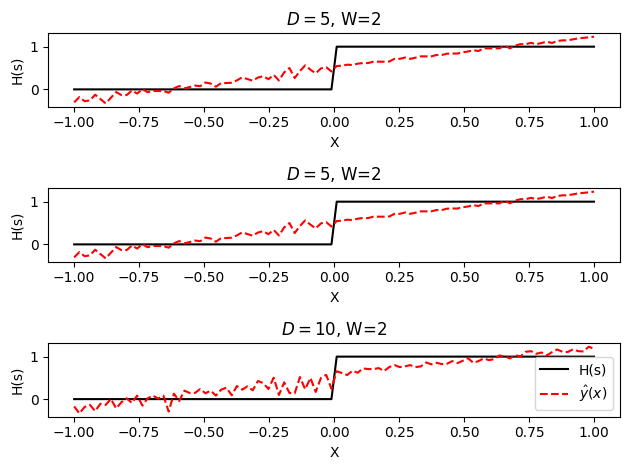

In [465]:


from importlib import reload

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from matplotlib import cm
from nonlinear_approximator import (
    activations,
    inference,
    model,
    params,
    training, 
)
from sklearn.linear_model import Ridge

%matplotlib inline

# Parameters 
config1 = params.RegressionParams(
    width=2,
    depth=5,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config2 = params.RegressionParams(
    width=2,
    depth=5,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

config3 = params.RegressionParams(
    width=2,
    depth=10,
    input_dimension=1,
    transform_type=activations.TransformType.TENT,
    transform_params= params.TentParams(mu=1.99),
    output_dimension=1,
)

def tent(x, mu=1.99):
    return mu * np.minimum(x, 1 - x)

def step(x):
    out = np.zeros_like(x)
    out[x > 0] = 1
    out[x == 0] = .5
    return out 

def compute_activations(neurons, input_x, config):
    num_samples, dim_input = input_x.shape
    # neurons have dim_input x config.width shape
    activations = np.zeros((num_samples, config.depth, config.width))
    for idx_sample in range(num_samples):
        for idx_layer in range(config.depth):
            if idx_layer == 0:
                activations[idx_sample, idx_layer, :] = (neurons.T @ input_x[idx_sample, :] + 1)/2
            else:
                activations[idx_sample, idx_layer, :] = tent(
                    activations[idx_sample, idx_layer - 1, :]
                )
    return activations
        
def flatten_activations(acts: NDArray[np.floating]) -> NDArray[np.floating]:
    num_samples, depth, width = acts.shape
    # return np.reshape(acts, (num_samples, depth * width))    
    flattened = np.zeros((num_samples, depth * width), dtype=np.float64)
    for idx_sample in range(num_samples):
        flattened[idx_sample, :] = np.copy(np.ravel(acts[idx_sample, :, :]))
        # for row in range(depth):
        #     for col in range(width):
        #         flattened[idx_sample, row * width  + col] = acts[row, col, idx_sample]
    return flattened

neurons = np.array([[-1, 1]])
xs = np.expand_dims(np.linspace(-1, 1, 100),axis=-1)
xs_test = np.random.uniform(-1, 1, (100,1) )
plt.figure('h')
plt.clf()

for idx, config in enumerate([config1, config2, config3]):
    plt.subplot(3,1,idx+1)
    plt.plot(xs, step(xs), label='H(s)', c='black')
    

    plt.xlabel("X")
    plt.ylabel("H(s)")
    plt.title(f"$D={config.depth}$, W={config.width}")


    # zero mean input
    acts_train = flatten_activations(compute_activations(
        neurons=neurons, input_x=xs, config=config
    ))
    acts_test = flatten_activations(activations.compute_activations(
        neurons=neurons, input_x=xs_test.T, config=config
    ))

    clf = Ridge(alpha=0)

    clf.fit(acts_train, step(xs))
    
    # preds = clf.predict(acts_test)
    preds_fit = clf.predict(acts_train)
    # if idx == 2:
    #     # inset Axes....
    #     x1, x2, y1, y2 = -1, -0.7, -.003, 0.004  # subregion of the original image
    #     ax = plt.gca()
    #     axins = ax.inset_axes(
    #         [0.15, 0.45, 0.2, 0.5],
    #         xlim=(x1, x2), ylim=(y1, y2))
    #     axins.plot(xs, preds, ls='dotted', c='g')
    #     axins.plot(xs, step(xs), label='H(x)', c='black')
        

    #     ax.indicate_inset_zoom(axins, edgecolor="black", )
    #     axins.ticklabel_format(style='scientific', axis='both', scilimits=(0, 0))
    # plt.plot(xs, preds, ls='--', c='g', label='$\hat{y}(x$)')
    plt.plot(xs, preds_fit, ls='--', c='r', label='$\hat{y}(x$)')
plt.legend()
plt.gcf().tight_layout()
plt.ion()
plt.show()

In [533]:
neurons.shape

(1, 2)

(2,)


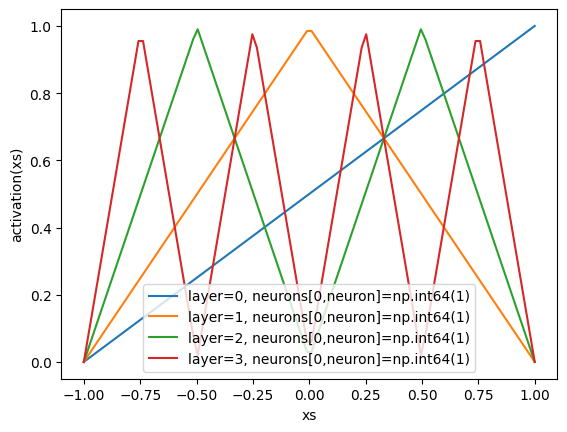

In [558]:
a = compute_activations(
        neurons=neurons, input_x=xs, config=config
    )

# activations have shape [num_samples x depth x width]
i = (neurons.T @ xs[0,:] + 1)/2
print(i.shape)
# neurons.shape, xs.shape
# neurons have shape [dim x num_neurons] 
# xs has shape [num samples x dim ]
a[:, 5, 1]
plt.figure('1')
plt.clf()
neuron = 1
for layer in [0, 1, 2, 3]:
    plt.plot(xs, a[:, layer, neuron], label=f'{layer=}, {neurons[0,neuron]=}')
plt.xlabel('xs')
plt.ylabel('activation(xs)')
plt.legend()

In [564]:
xs.shape

(100, 1)

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747